<a href="https://colab.research.google.com/github/wajahat201/Dog-Vs-Cat-Detection-/blob/main/project_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os

os.environ['KAGGLE_USERNAME'] = 'wajahatsaif'
os.environ['KAGGLE_KEY'] = 'KGAT_06c0557c22cfe914ad7ee253fc4d6611'

In [2]:
!pip install -q kaggle
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [01:01<00:00, 18.4MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [4]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',                 # folder name  (cats/dogs)
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [6]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

def process(image, label):
    image = tf.cast(image / 255., tf.float32)  # pixel 0-255 → 0.0-1.0
    return image, label

# Augmentation  on training data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(process)

validation_ds = validation_ds.map(process)

# Speed optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

Model Architecutre

In [7]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # slow & steady learning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    # val_loss 4 epochs tak improve na ho → training band karo, best weights restore

    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    # val_loss 2 epochs tak improve na ho → learning rate aadha karo
]

history = model.fit(
    train_ds,
    epochs=20,               # max 20 epochs
    validation_data=validation_ds,
    callbacks=callbacks
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 154ms/step - accuracy: 0.6314 - loss: 0.7751 - val_accuracy: 0.6090 - val_loss: 1.0252 - learning_rate: 5.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6923 - loss: 0.5782 - val_accuracy: 0.6880 - val_loss: 0.6804 - learning_rate: 5.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7291 - loss: 0.5398 - val_accuracy: 0.7110 - val_loss: 0.5834 - learning_rate: 5.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7685 - loss: 0.4857 - val_accuracy: 0.7540 - val_loss: 0.6735 - learning_rate: 5.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7908 - loss: 0.4485 - val_accuracy: 0.7058 - val_loss: 1.0917 - learning_rate: 5.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8250 - loss: 0.3783 - val_accuracy: 0.7440 - val_loss: 1.0532 - learning_rate: 2.5000e-04
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/s

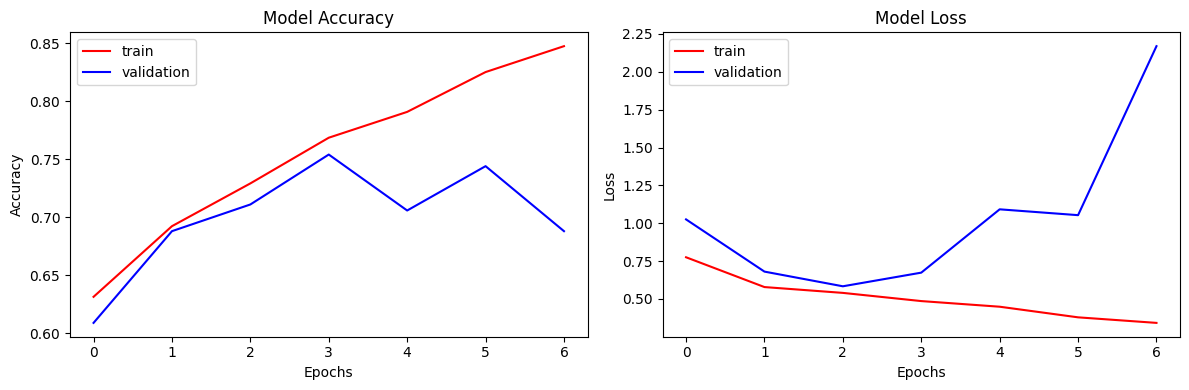

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

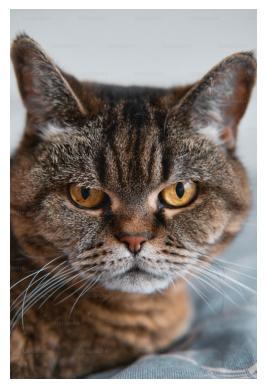

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Raw Prediction Value: 0.0002
Prediction: It's a CAT! (confidence: 100.0%)


In [24]:
image_path = '/content/premium_photo-1667030474693-6d0632f97029.avif'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)

    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    plt.imshow(test_img_rgb); plt.axis('off'); plt.show()

    test_img_resized = cv2.resize(test_img_rgb, (128, 128))

    test_input = test_img_resized.astype('float32') / 255.0

    test_input = test_input.reshape((1, 128, 128, 3))

    prediction = model.predict(test_input)
    prob = prediction[0][0]
    print(f"Raw Prediction Value: {prob:.4f}")

    if prob < 0.5:
        print(f"Prediction: It's a CAT! (confidence: {(1-prob)*100:.1f}%)")
    else:
        print(f"Prediction: It's a DOG! (confidence: {prob*100:.1f}%)")